### 0. Content page

1. Load packages and data
2. Helper functions
3. Rebuild long / short / net returns
4. Core performance table
5. Cumulative performance plot: Long / Net
6. Drawdown plot
7. Return histogram
8. Long vs short correlation and descriptive stats
9. Signal diagnostics: dividend per share (dps), p/b ratio, free cash flow yield, monthly momentum, mean reversal signal
10. Universe size over time
11. Portfolio breadth over time
12. Long composition
13. Benchmark comparison vs S&P 500
14. Turnover
15. A compact text summary cell for every model

### 1. Load packages and data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
RESULT_DIR = "../tables/value_top1000_market_cap_top50_long_only"
STRATEGY_NAME = "Value Strategy"

In [3]:
portfolio_returns = pd.read_csv(f"{RESULT_DIR}/portfolio_returns.csv")
asset_returns = pd.read_csv(f"{RESULT_DIR}/asset_returns.csv")
weights_at_E = pd.read_csv(f"{RESULT_DIR}/weights_at_E.csv")
signals_at_T = pd.read_csv(f"{RESULT_DIR}/signals_at_T.csv")

try:
    portfolio_membership_at_T = pd.read_csv(f"{RESULT_DIR}/portfolio_membership_at_T.csv")
except FileNotFoundError:
    portfolio_membership_at_T = None

In [4]:
for c in ["signal_date", "execution_date", "next_execution_date"]:
    if c in portfolio_returns.columns:
        portfolio_returns[c] = pd.to_datetime(portfolio_returns[c])

for c in ["signal_date", "execution_date", "next_execution_date", "actual_exit_date"]:
    if c in asset_returns.columns:
        asset_returns[c] = pd.to_datetime(asset_returns[c])

for c in ["signal_date", "execution_date"]:
    if c in weights_at_E.columns:
        weights_at_E[c] = pd.to_datetime(weights_at_E[c])

if "signal_date" in signals_at_T.columns:
    signals_at_T["signal_date"] = pd.to_datetime(signals_at_T["signal_date"])

if portfolio_membership_at_T is not None:
    for c in ["signal_date", "execution_date"]:
        if c in portfolio_membership_at_T.columns:
            portfolio_membership_at_T[c] = pd.to_datetime(portfolio_membership_at_T[c])

In [5]:
print("portfolio_returns:", portfolio_returns.shape)
print("asset_returns:", asset_returns.shape)
print("weights_at_E:", weights_at_E.shape)
print("signals_at_T:", signals_at_T.shape)
if portfolio_membership_at_T is not None:
    print("portfolio_membership_at_T:", portfolio_membership_at_T.shape)

portfolio_returns: (238, 4)
asset_returns: (11900, 11)
weights_at_E: (11900, 27)
signals_at_T: (237032, 23)
portfolio_membership_at_T: (11900, 26)


### 2. Helper functions

In [6]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0 or monthly_returns.std() == 0:
        return np.nan
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

def max_drawdown(return_series: pd.Series) -> float:
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

### 3. Rebuild long / short / net returns

In [7]:
monthly = (
    asset_returns
    .groupby(["signal_date", "execution_date", "next_execution_date"], as_index=False)["weighted_return"]
    .sum()
    .rename(columns={"weighted_return": "portfolio_return_rebuilt"})
)

monthly.head()

,signal_date,execution_date,next_execution_date,portfolio_return_rebuilt
0,2006-02-28,2006-03-01,2006-04-03,0.006442
1,2006-03-31,2006-04-03,2006-05-01,0.018252
2,2006-04-28,2006-05-01,2006-06-01,-0.018756
3,2006-05-31,2006-06-01,2006-07-03,-0.003276
4,2006-06-30,2006-07-03,2006-08-01,-0.021323


In [8]:
check = portfolio_returns.merge(
    monthly,
    on=["signal_date", "execution_date", "next_execution_date"],
    how="inner"
)

check["diff"] = check["portfolio_return"] - check["portfolio_return_rebuilt"]

print("max abs diff:", check["diff"].abs().max())
print("nonzero diff rows:", (check["diff"].abs() > 1e-12).sum())

max abs diff: 2.609024107869118e-15
nonzero diff rows: 0


### 4. Core performance table

In [9]:
summary_table = pd.DataFrame({
    "long_only_portfolio": performance_summary(monthly["portfolio_return_rebuilt"]),
}).T

summary_table

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
long_only_portfolio,0.011987,0.076092,0.545703,0.613445,-0.681042


### 5. Cumulative performance plot: Long / Net

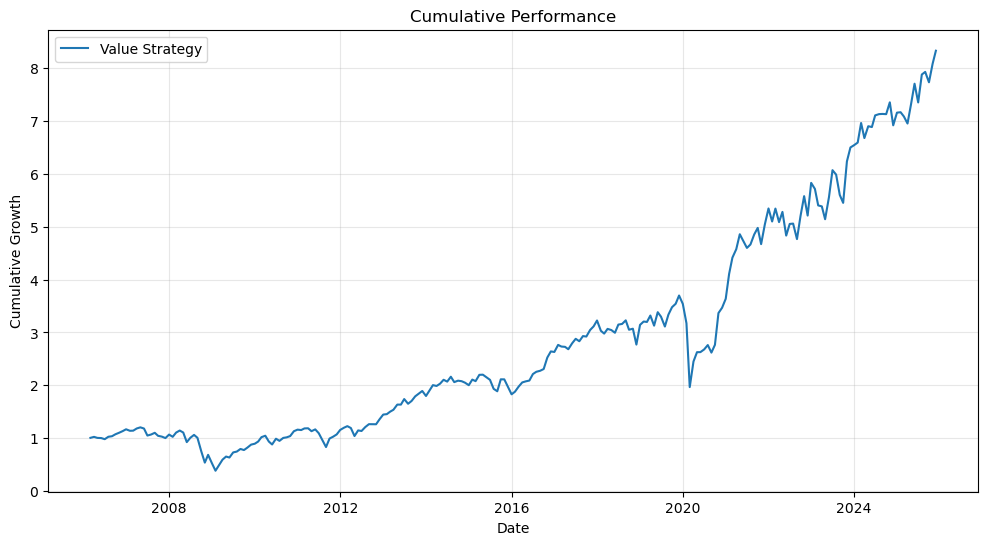

In [10]:
plot_df = monthly.sort_values("signal_date").copy()
plot_df["cum_portfolio"] = (1 + plot_df["portfolio_return_rebuilt"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["signal_date"], plot_df["cum_portfolio"], label="Value Strategy")
plt.title("Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Drawdown plot

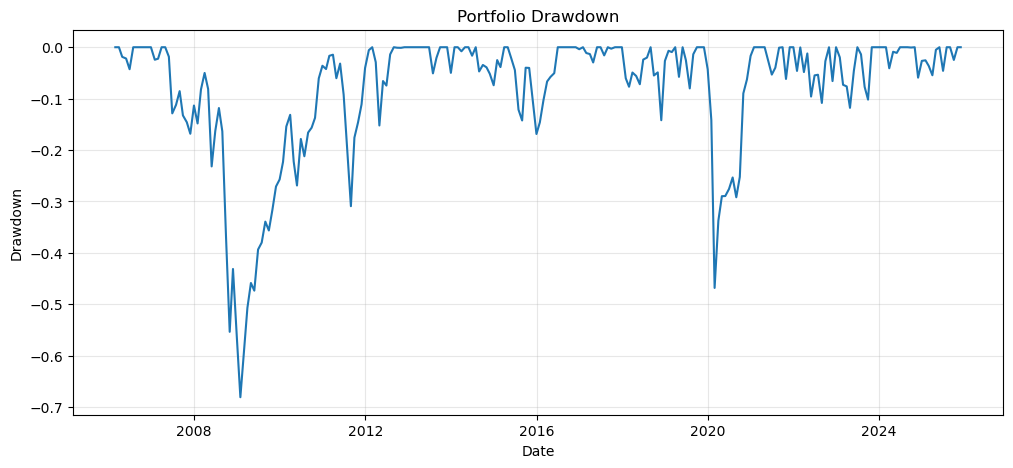

In [11]:
drawdown_df = plot_df[["signal_date", "portfolio_return_rebuilt"]].copy()
drawdown_df["cum"] = (1 + drawdown_df["portfolio_return_rebuilt"]).cumprod()
drawdown_df["roll_max"] = drawdown_df["cum"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum"] / drawdown_df["roll_max"] - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown_df["signal_date"], drawdown_df["drawdown"])
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

### 7. Return histogram

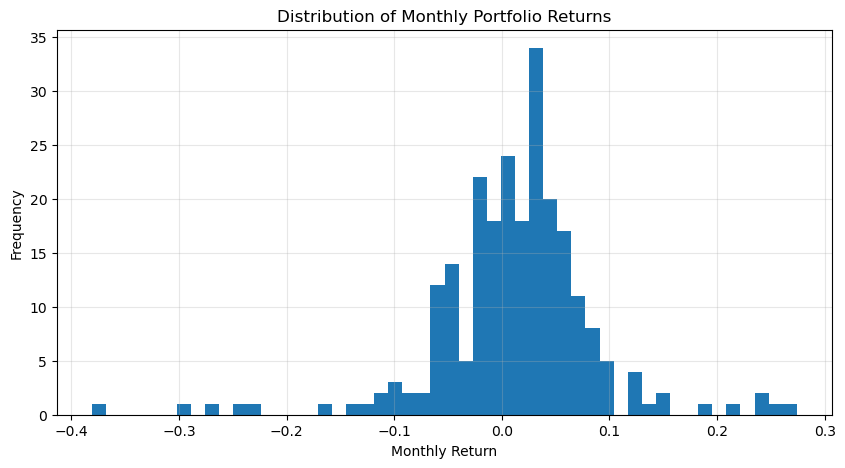

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(monthly["portfolio_return_rebuilt"], bins=50)
plt.title("Distribution of Monthly Portfolio Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 8. Long vs short correlation and descriptive stats

In [13]:
monthly["portfolio_return_rebuilt"].describe()

count    238.000000
mean       0.011987
std        0.076092
min       -0.380530
25%       -0.020486
50%        0.018858
75%        0.046571
max        0.274061
Name: portfolio_return_rebuilt, dtype: float64

In [14]:
signal_cols_to_check = [
    c for c in ["dps_proxy", "pb", "fcf_yield", "mom_1m", "reversal_signal"]
    if c in weights_at_E.columns
]
signal_cols_to_check

['pb', 'fcf_yield', 'mom_1m', 'reversal_signal']

In [15]:
for col in signal_cols_to_check:
    print(f"\n=== {col} ===")
    display(weights_at_E[col].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


=== pb ===


count    11900.000000
mean         1.064277
std          0.639117
min          0.000213
1%           0.000449
5%           0.008916
50%          1.016759
95%          2.115351
99%          3.145176
max          9.083966
Name: pb, dtype: float64


=== fcf_yield ===


count    11900.000000
mean         6.069869
std         35.202722
min          0.003401
1%           0.044017
5%           0.066649
50%          0.166123
95%          5.522580
99%        191.669575
max        637.823980
Name: fcf_yield, dtype: float64


=== mom_1m ===


count    11900.000000
mean        -0.052037
std          0.085981
min         -0.843476
1%          -0.362721
5%          -0.198725
50%         -0.040289
95%          0.057029
99%          0.110114
max          0.324074
Name: mom_1m, dtype: float64


=== reversal_signal ===


count    11900.000000
mean         0.052037
std          0.085981
min         -0.324074
1%          -0.110114
5%          -0.057029
50%          0.040289
95%          0.198725
99%          0.362721
max          0.843476
Name: reversal_signal, dtype: float64

### 9. Signal diagnostics: dividend per share (dps), p/b ratio, free cash flow yield, monthly momentum, mean reversal signal

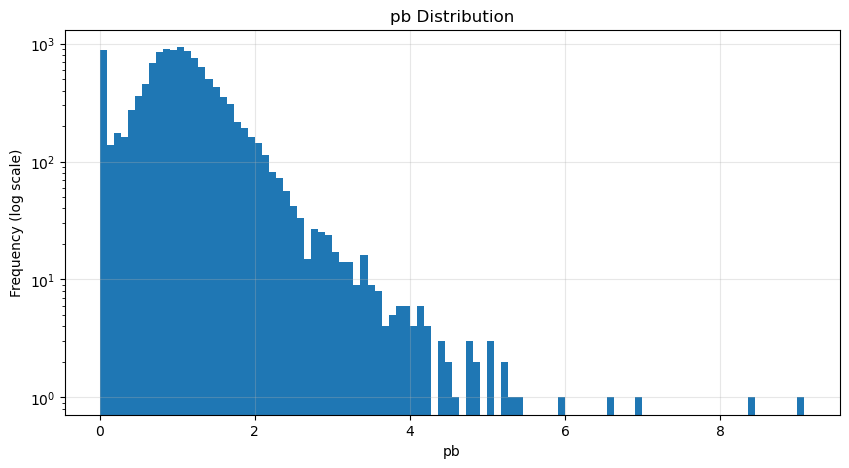

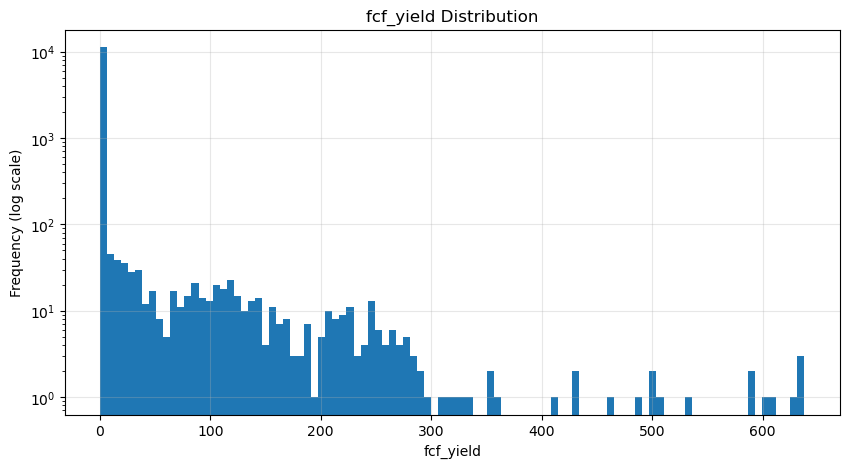

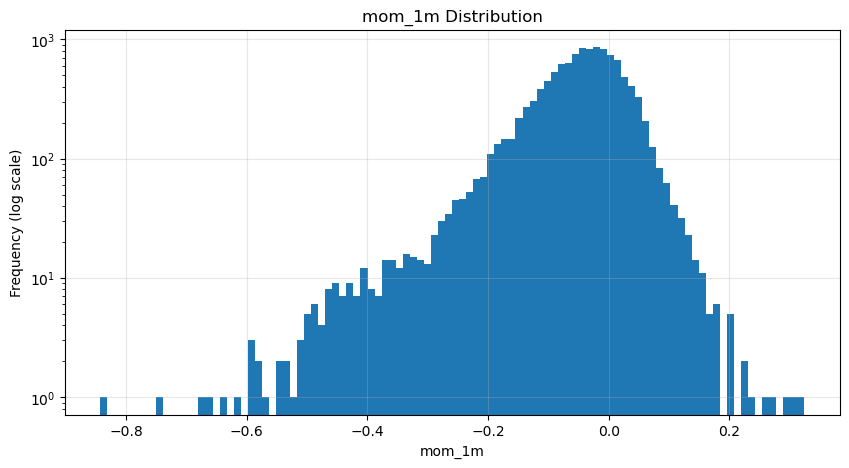

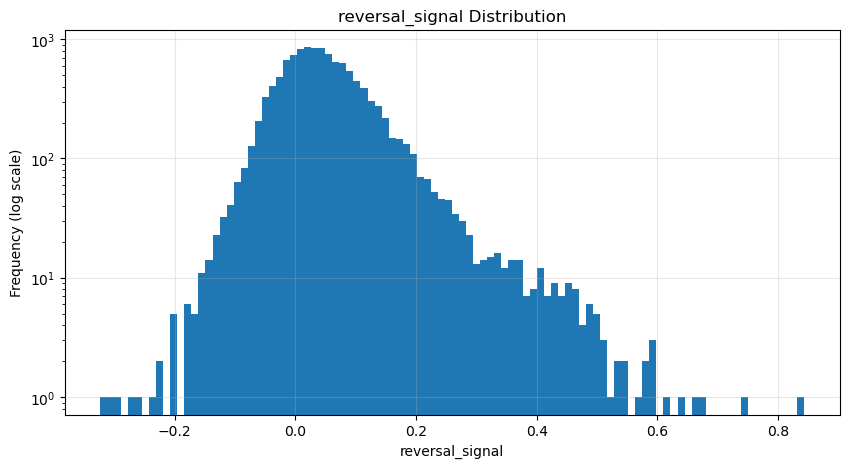

In [16]:
for col in signal_cols_to_check:
    plt.figure(figsize=(10, 5))
    plt.hist(weights_at_E[col].dropna(), bins=100)
    plt.yscale("log")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency (log scale)")
    plt.grid(True, alpha=0.3)
    plt.show()

### 10. Universe size over time

In [17]:
universe_size = (
    signals_at_T.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_universe")
)

universe_size.head()

,signal_date,n_universe
0,2006-02-28,987
1,2006-03-31,991
2,2006-04-28,991
3,2006-05-31,991
4,2006-06-30,994


In [18]:
universe_size["n_universe"].describe()

count     238.000000
mean      995.932773
std         3.836822
min       982.000000
25%       995.000000
50%       997.000000
75%       998.750000
max      1000.000000
Name: n_universe, dtype: float64

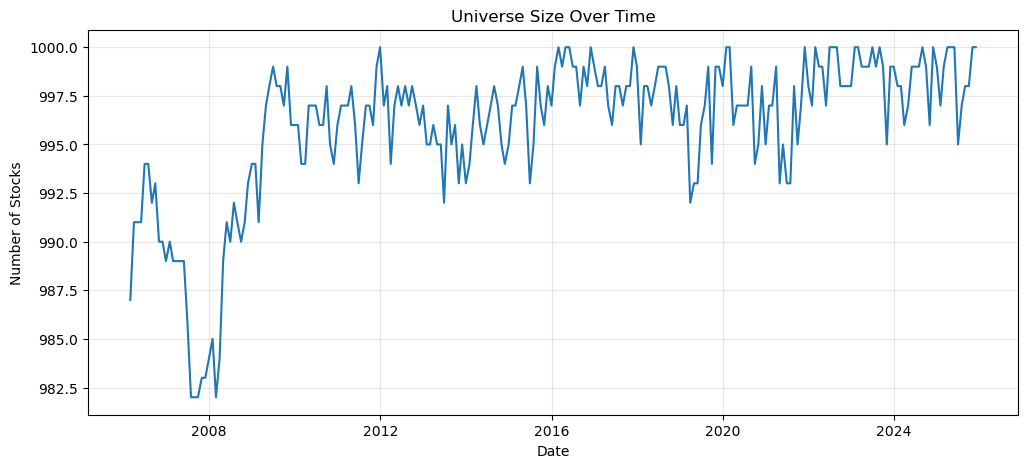

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(universe_size["signal_date"], universe_size["n_universe"])
plt.title("Universe Size Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)
plt.show()

### 11. Portfolio breadth over time

In [20]:
breadth = (
    asset_returns.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_long")
)

breadth.head()

,signal_date,n_long
0,2006-02-28,50
1,2006-03-31,50
2,2006-04-28,50
3,2006-05-31,50
4,2006-06-30,50


In [21]:
breadth["n_long"].describe()

count    238.0
mean      50.0
std        0.0
min       50.0
25%       50.0
50%       50.0
75%       50.0
max       50.0
Name: n_long, dtype: float64

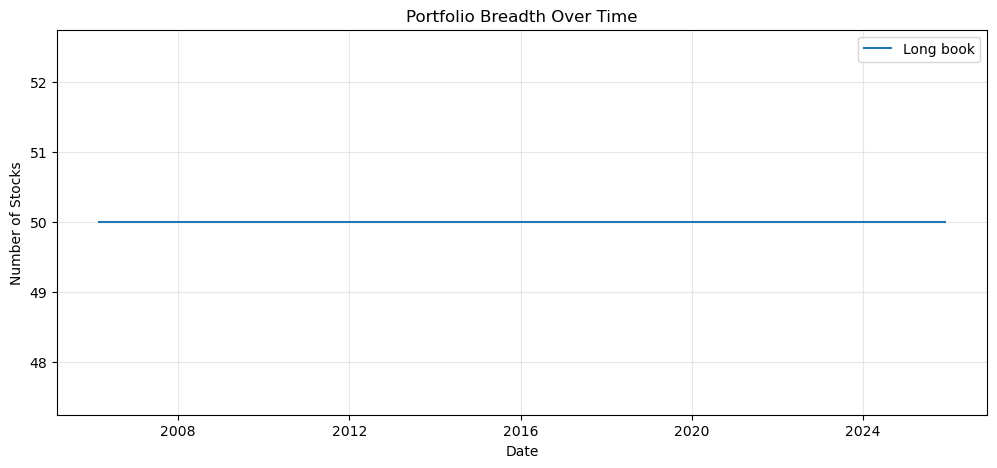

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(breadth["signal_date"], breadth["n_long"], label="Long book")
plt.title("Portfolio Breadth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12. Long composition

In [23]:
factor_cols = [
    c for c in ["market_cap", "pb", "dps_proxy", "fcf_yield", "mom_1m", "reversal_signal"]
    if c in weights_at_E.columns
]

factor_summary = weights_at_E[factor_cols].mean().to_frame("long_book_mean")
factor_summary

,long_book_mean
market_cap,2.222939e+10
pb,1.064277e+00
fcf_yield,6.069869e+00
mom_1m,-5.203668e-02
reversal_signal,5.203668e-02


In [24]:
factor_check = (
    weights_at_E
    .groupby("signal_date")[factor_cols]
    .mean()
    .reset_index()
)

factor_check.head()

,signal_date,market_cap,pb,fcf_yield,mom_1m,reversal_signal
0,2006-02-28,1.195118e+10,1.327003,2.663563,-0.055229,0.055229
1,2006-03-31,1.461901e+10,1.450220,2.774922,-0.026265,0.026265
2,2006-04-28,5.157358e+09,1.488858,0.201351,-0.044604,0.044604
3,2006-05-31,1.019282e+10,1.393769,2.899778,-0.080778,0.080778
4,2006-06-30,1.652563e+10,1.431852,3.173417,-0.048185,0.048185


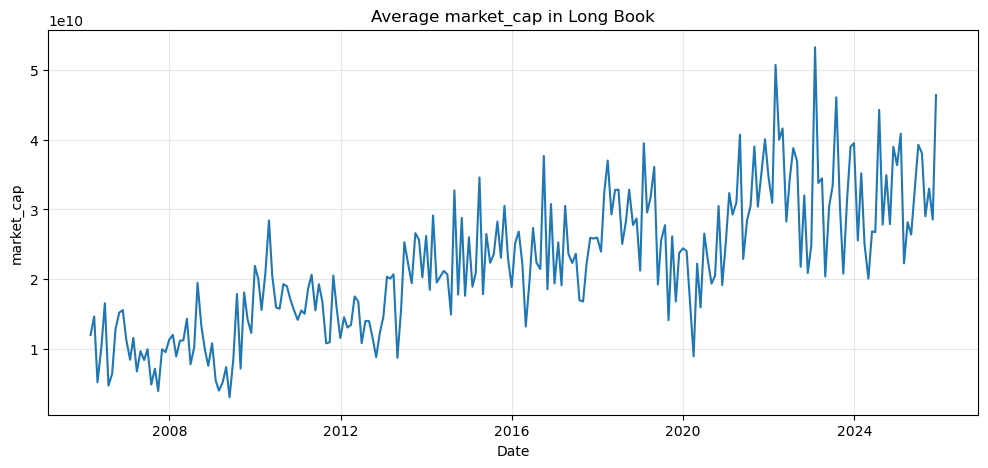

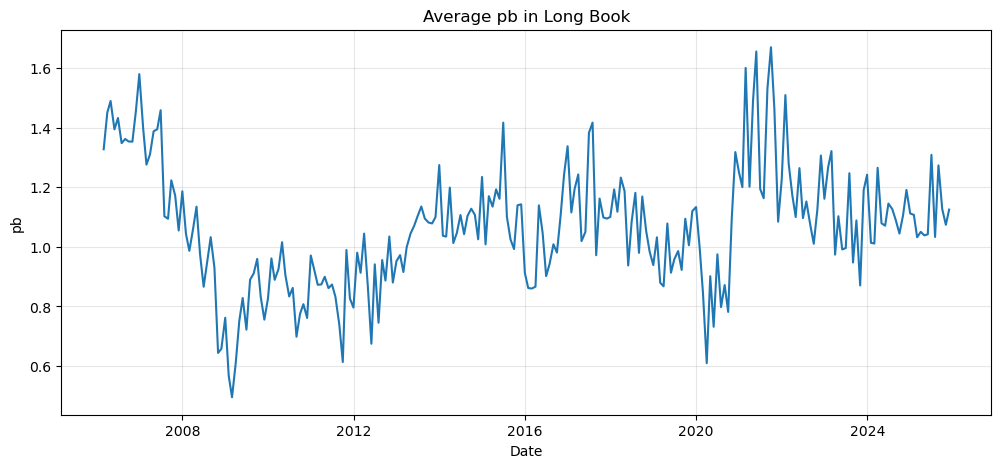

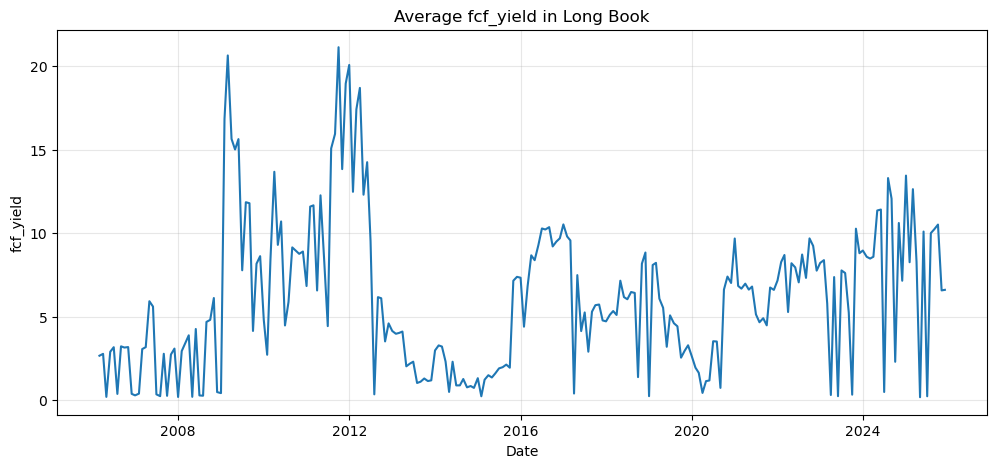

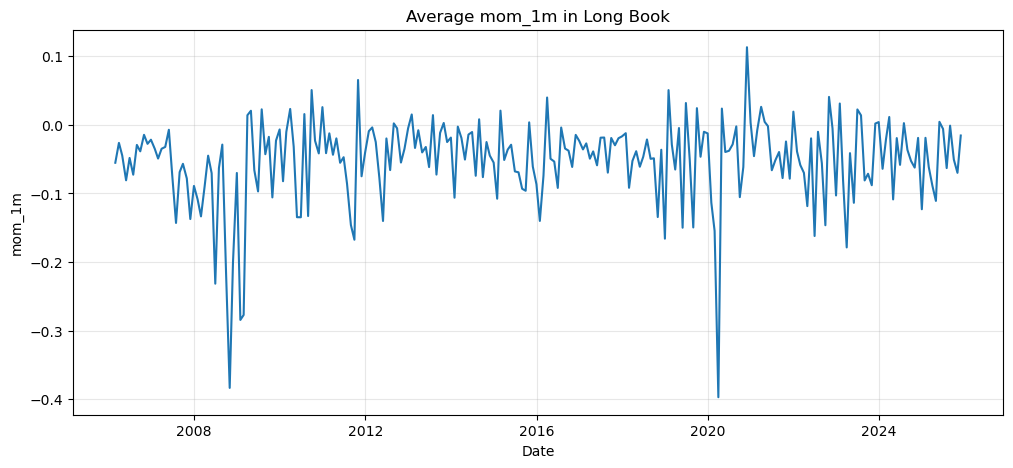

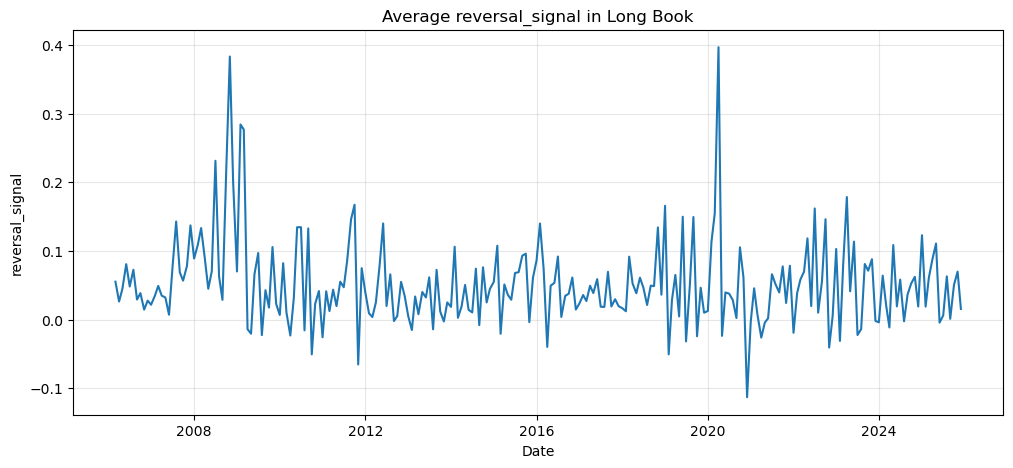

In [25]:
for col in factor_cols:
    plt.figure(figsize=(12, 5))
    plt.plot(factor_check["signal_date"], factor_check[col])
    plt.title(f"Average {col} in Long Book")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

### 13. Benchmark comparison vs S&P 500

In [39]:
sp = yf.download(
    "^GSPC",
    start="1996-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=False
)

sp_price = sp[("Adj Close", "^GSPC")]

sp_monthly = (
    sp_price
    .resample("ME")
    .last()
    .pct_change()
    .dropna()
    .to_frame("sp_return")
    .reset_index()
    .rename(columns={"Date": "sp_signal_date"})
)

sp_monthly["sp_signal_date"] = pd.to_datetime(sp_monthly["sp_signal_date"])
sp_monthly["month"] = sp_monthly["sp_signal_date"].dt.to_period("M")

sp_monthly.head()

,sp_signal_date,sp_return,month
0,1996-02-29,0.006934,1996-02
1,1996-03-31,0.007917,1996-03
2,1996-04-30,0.013431,1996-04
3,1996-05-31,0.022853,1996-05
4,1996-06-30,0.002257,1996-06


In [40]:
portfolio_returns["signal_date"] = pd.to_datetime(portfolio_returns["signal_date"])
portfolio_returns = portfolio_returns.sort_values("signal_date").reset_index(drop=True)
portfolio_returns["month"] = portfolio_returns["signal_date"].dt.to_period("M")

sp_monthly = sp_monthly.sort_values("sp_signal_date").reset_index(drop=True)

In [41]:
merged = pd.merge(
    portfolio_returns,
    sp_monthly[["month", "sp_signal_date", "sp_return"]],
    on="month",
    how="inner"
)

print(merged.shape)
merged.head()

(238, 7)


,signal_date,execution_date,next_execution_date,portfolio_return,month,sp_signal_date,sp_return
0,2006-02-28,2006-03-01,2006-04-03,0.006442,2006-02,2006-02-28,0.000453
1,2006-03-31,2006-04-03,2006-05-01,0.018252,2006-03,2006-03-31,0.011096
2,2006-04-28,2006-05-01,2006-06-01,-0.018756,2006-04,2006-04-30,0.012156
3,2006-05-31,2006-06-01,2006-07-03,-0.003276,2006-05,2006-05-31,-0.030917
4,2006-06-30,2006-07-03,2006-08-01,-0.021323,2006-06,2006-06-30,0.000087


In [43]:
merged["cum_value"] = (1 + merged["portfolio_return"]).cumprod()
merged["cum_sp"] = (1 + merged["sp_return"]).cumprod()

merged[[
    "signal_date", "sp_signal_date", "portfolio_return", "sp_return",
    "cum_value", "cum_sp"
]].head()

,signal_date,sp_signal_date,portfolio_return,sp_return,cum_value,cum_sp
0,2006-02-28,2006-02-28,0.006442,0.000453,1.006442,1.000453
1,2006-03-31,2006-03-31,0.018252,0.011096,1.024811,1.011554
2,2006-04-28,2006-04-30,-0.018756,0.012156,1.005590,1.023850
3,2006-05-31,2006-05-31,-0.003276,-0.030917,1.002295,0.992196
4,2006-06-30,2006-06-30,-0.021323,0.000087,0.980923,0.992282


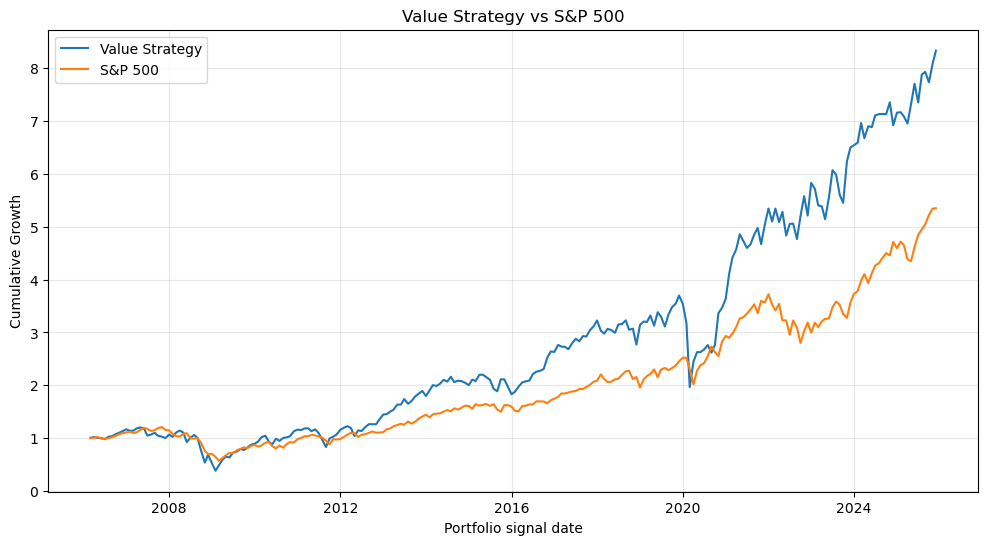

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(merged["signal_date"], merged["cum_value"], label="Value Strategy")
plt.plot(merged["signal_date"], merged["cum_sp"], label="S&P 500")
plt.title("Value Strategy vs S&P 500")
plt.xlabel("Portfolio signal date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
print("Value Strategy Sharpe:", annualized_sharpe(merged["portfolio_return"]))
print("S&P 500 Sharpe:", annualized_sharpe(merged["sp_return"]))

Value Strategy Sharpe: 0.7399663130375437
S&P 500 Sharpe: 0.6271436596297293


In [32]:
benchmark_summary = pd.DataFrame({
    "Value Strategy": performance_summary(merged["portfolio_return"]),
    "S&P 500": performance_summary(merged["sp_return"]),
}).T

benchmark_summary

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
Value Strategy,0.014697,0.068803,0.739966,0.636905,-0.591632
S&P 500,0.008028,0.044342,0.627144,0.636905,-0.391858


### 14. Turnover

In [33]:
membership_sets = (
    weights_at_E.groupby("signal_date")["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
    .sort_values("signal_date")
    .reset_index(drop=True)
)

turnover_records = []
for i in range(1, len(membership_sets)):
    prev_set = membership_sets.loc[i - 1, "ticker_set"]
    curr_set = membership_sets.loc[i, "ticker_set"]

    entered = len(curr_set - prev_set)
    exited = len(prev_set - curr_set)
    union_n = len(curr_set | prev_set)
    prev_n = len(prev_set)

    turnover_records.append({
        "signal_date": membership_sets.loc[i, "signal_date"],
        "entered": entered,
        "exited": exited,
        "turnover_rate_vs_prev": (entered + exited) / prev_n if prev_n > 0 else np.nan,
        "jaccard_similarity": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
    })

turnover_df = pd.DataFrame(turnover_records)
turnover_df.head()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
0,2006-03-31,27,27,1.08,0.298701
1,2006-04-28,32,32,1.28,0.219512
2,2006-05-31,28,28,1.12,0.282051
3,2006-06-30,29,29,1.16,0.265823
4,2006-07-31,26,26,1.04,0.315789


In [34]:
turnover_df.describe()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
count,237,237.000000,237.000000,237.000000,237.000000
mean,2016-01-29 15:23:32.658227968,26.940928,26.940928,1.077637,0.303364
min,2006-03-31 00:00:00,16.000000,16.000000,0.640000,0.136364
25%,2011-02-28 00:00:00,24.000000,24.000000,0.960000,0.250000
50%,2016-01-29 00:00:00,27.000000,27.000000,1.080000,0.298701
75%,2020-12-31 00:00:00,30.000000,30.000000,1.200000,0.351351
max,2025-11-28 00:00:00,38.000000,38.000000,1.520000,0.515152
std,NaN,4.074088,4.074088,0.162964,0.069693


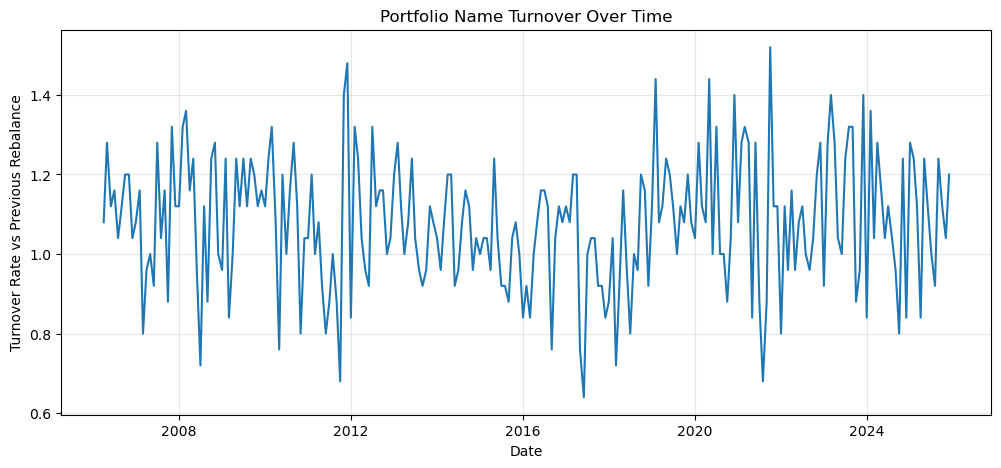

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_df["signal_date"], turnover_df["turnover_rate_vs_prev"])
plt.title("Portfolio Name Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover Rate vs Previous Rebalance")
plt.grid(True, alpha=0.3)
plt.show()

### 15. A compact text summary cell for every model

In [36]:
print("=== MODEL SUMMARY ===")
print(f"Annualized Sharpe: {annualized_sharpe(monthly['portfolio_return_rebuilt']):.4f}")
print(f"Max drawdown: {max_drawdown(monthly['portfolio_return_rebuilt']):.4f}")
print(f"Average universe size: {universe_size['n_universe'].mean():.2f}")
print(f"Average long breadth: {breadth['n_long'].mean():.2f}")
print(f"Average turnover: {turnover_df['turnover_rate_vs_prev'].mean():.4f}")

=== MODEL SUMMARY ===
Annualized Sharpe: 0.5457
Max drawdown: -0.6810
Average universe size: 995.93
Average long breadth: 50.00
Average turnover: 1.0776
